# Introduction NV Center: Rabi Frequency, Nitrogen spin not considered (Simulating FIG 3 in Reference 1, a Work in Progress)
#### Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay
#### Reference 1: Digital Twin Simulations Toolbox of the Nitrogen-Vacancy Center in Diamond, Lucas Tsunaki et. al. (https://arxiv.org/abs/2507.18759)
#### Email: vineeth.thalakottoor@cea.fr

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)
import numpy as np
import scipy.constants as cte

import time
%matplotlib ipympl

# Import PyOR package
from PyORv2 import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QunS                   (QuantumSystem from PyOR_QuantumSystem)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalConstants)
** gamma                 (from PyOR_Gamma)
* QunObj                 (from PyOR_QuantumObject)
* QuantumLibrary      

In [2]:
# Define the spin system
Spin_list = {"A" : "NV_E", "B" : "C13"}
QS = QunS(Spin_list,PrintDefault=False)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [3]:
QS.Configure(
    # Propagation Space
    PropagationSpace="Hilbert",

    # Master Equation
    MasterEquation="Lindblad",

    # Operator basis
    Basis_SpinOperators_Hilbert="Zeeman",

    # Field in TFalse
    B0=0.200,

    # Relaxation process
    Rprocess="user Defined Dissipator",

    # Evolution parameters
    AcqDT = 3.0e-9,
    AcqAQ = 2.5e-6,
    OdeMethod = 'RK23',
    PropagationMethod = "ODE Solver ShapedPulse Lindblad",
    
    #Plotting
    PlotFigureSize = (10,5),
    PlotFontSize = 20
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [35217194000.0, -13456568.0] from {'A': 35217194000.0, 'B': -13456568.0}
Offset    <- OFFSET    : [0, 0] from {'A': 0, 'B': 0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [ 5.60499051e+03 -2.14167931e+00]
Larmor Frequency in MHz:  [ 5.60499051e+03 -2.14167931e+00]
Larmor Frequency in MHz:  [ 5.60499051e+03 -2.14167931e+00]


### Generate Hamiltonians

In [4]:
# Zero-field splitting NV Center
D = 2.8e9
E = 0.0    
Hzfs_sub = D * QS.Az_sub * QS.Az_sub + E * (QS.Ax_sub * QS.Ax_sub - QS.Ay_sub * QS.Ay_sub)
Hzfs_sub.matrix

Matrix([
[2800000000.0, 0,            0],
[           0, 0,            0],
[           0, 0, 2800000000.0]])

In [5]:
Hzfs = Hzfs_sub.TensorProduct(QS.Bid_sub)
Hzfs.matrix

Matrix([
[2800000000.0,            0, 0, 0,            0,            0],
[           0, 2800000000.0, 0, 0,            0,            0],
[           0,            0, 0, 0,            0,            0],
[           0,            0, 0, 0,            0,            0],
[           0,            0, 0, 0, 2800000000.0,            0],
[           0,            0, 0, 0,            0, 2800000000.0]])

In [6]:
# Electron Zeeman
Theta = 0.0
Phi = 0.0
Hez_sub = -gamma("E") * QS.B0 * (np.cos(Theta) * QS.Az_sub + np.sin(Theta) * np.cos(Phi) * QS.Ax_sub +  np.sin(Theta) * np.sin(Phi) * QS.Ay_sub)
Hez_sub.matrix

Matrix([
[35217194000.0, 0,              0],
[            0, 0,              0],
[            0, 0, -35217194000.0]])

In [7]:
Hez = Hez_sub.TensorProduct(QS.Bid_sub)
Hez.matrix

Matrix([
[35217194000.0,             0, 0, 0,              0,              0],
[            0, 35217194000.0, 0, 0,              0,              0],
[            0,             0, 0, 0,              0,              0],
[            0,             0, 0, 0,              0,              0],
[            0,             0, 0, 0, -35217194000.0,              0],
[            0,             0, 0, 0,              0, -35217194000.0]])

In [8]:
# Introducing NV center and C13 interaction
Azz = 130.0e6
H2 = Azz * QS.Az * QS.Bz - gamma("C13") * QS.B0 * QS.Bz
H2.matrix

Matrix([
[58271716.0,           0,          0,         0,           0,          0],
[         0, -58271716.0,          0,         0,           0,          0],
[         0,           0, -6728284.0,         0,           0,          0],
[         0,           0,          0, 6728284.0,           0,          0],
[         0,           0,          0,         0, -71728284.0,          0],
[         0,           0,          0,         0,           0, 71728284.0]])

In [9]:
# Total Hamiltonian (Time independent)
Htotal = Hzfs + Hez + H2
Htotal.matrix

Matrix([
[38075465716.0,             0,          0,         0,              0,              0],
[            0, 37958922284.0,          0,         0,              0,              0],
[            0,             0, -6728284.0,         0,              0,              0],
[            0,             0,          0, 6728284.0,              0,              0],
[            0,             0,          0,         0, -32488922284.0,              0],
[            0,             0,          0,         0,              0, -32345465716.0]])

In [10]:
# Transition frequency (0 to 1: Nuclear, 0 to 2 NV)
f01 = QS.Hamiltonian.EnergyLevel_TransitionFrequency(Htotal, initial=0, final=1) # Radiowave Freq
f02 = QS.Hamiltonian.EnergyLevel_TransitionFrequency(Htotal, initial=0, final=2) # Microwave Freq

In [11]:
# Zeeman states
QS.ZeemanBasis_Ket()

['|1,1⟩|1/2,1/2⟩',
 '|1,1⟩|1/2,-1/2⟩',
 '|1,0⟩|1/2,1/2⟩',
 '|1,0⟩|1/2,-1/2⟩',
 '|1,-1⟩|1/2,1/2⟩',
 '|1,-1⟩|1/2,-1/2⟩']

In [12]:
# Interaction with external microwave or radio waves
w1_S = 2.0 * np.pi * 20e6  # B1 Microwave
w1_I = 2.0 * np.pi * 0.8e6 # B1 Radiowave	
w0_mw = f02
w0_rf = f01
def H_1(t):
    return -1 * (w1_S * np.sqrt(2.0) * QS.Ax + w1_I * 2.0 * QS.Bx) * np.cos(-w0_rf * t) 


## Initialize density matrix (C13)

In [13]:
rho_in = QS.State({"A": -1,"B": 1/2}) * QS.State({"A": -1,"B": 1/2}).Tranpose()
rho_in.matrix

Matrix([
[0, 0, 0, 0,   0, 0],
[0, 0, 0, 0,   0, 0],
[0, 0, 0, 0,   0, 0],
[0, 0, 0, 0,   0, 0],
[0, 0, 0, 0, 1.0, 0],
[0, 0, 0, 0,   0, 0]])

In [14]:
ket_int = QS.State({"A": -1,"B": 1/2})
ket_int.matrix

Matrix([
[  0],
[  0],
[  0],
[  0],
[1.0],
[  0]])

## Evolution

In [15]:
QS.Configure(
    uDissipator = [(1.0e6, QS.Bz, QS.Bz.Adjoint())],
    uDissipator_only_anticomm = False,  # Select Haberkorn (True) or Lindblad (False)
    ShapeFunc_or_Hamiltonian = "User Defined Hamiltonian"
)

start_time = time.time()
QS.Evolutions.Set_UserDefinedHamiltonian(H_1)
t, rho_t = QS.Evolutions.Evolution(rho_in,rho_in,Htotal)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [35217194000.0, -13456568.0] from {'A': 35217194000.0, 'B': -13456568.0}
Offset    <- OFFSET    : [0, 0] from {'A': 0, 'B': 0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [ 5.60499051e+03 -2.14167931e+00]
Larmor Frequency in MHz:  [ 5.60499051e+03 -2.14167931e+00]
Larmor Frequency in MHz:  [ 5.60499051e+03 -2.14167931e+00]
Total time = 1391.515237569809 seconds 


## Expectation

In [16]:
det_Fs = QS.Aid_sub.TensorProduct(QS.States_Coupled([{"B": 1/2}]) * QS.States_Coupled([{"B": 1/2}]).Tranpose())

t,Fs = QS.Evolutions.Expectation(rho_t,det_Fs)

In [17]:
det_Fs.matrix

Matrix([
[1.0, 0,   0, 0,   0, 0],
[  0, 0,   0, 0,   0, 0],
[  0, 0, 1.0, 0,   0, 0],
[  0, 0,   0, 0,   0, 0],
[  0, 0,   0, 0, 1.0, 0],
[  0, 0,   0, 0,   0, 0]])

## Plotting

/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x70e02b94ce30>)

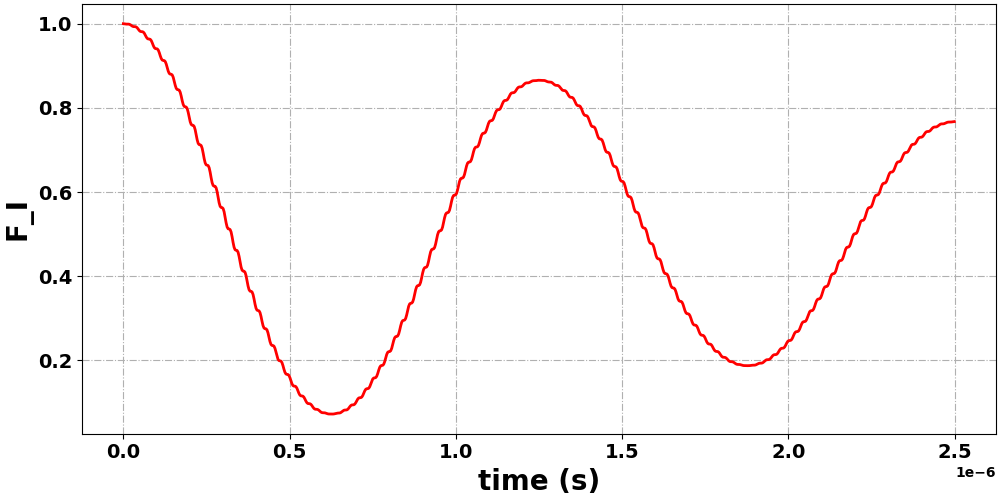

In [18]:
QS.Plotting.Plotting_SpanSelector(t,Fs,"time (s)","F_I","red") 

In [19]:
QS.Az.Adjoint().matrix

Matrix([
[1.0,   0, 0, 0,    0,    0],
[  0, 1.0, 0, 0,    0,    0],
[  0,   0, 0, 0,    0,    0],
[  0,   0, 0, 0,    0,    0],
[  0,   0, 0, 0, -1.0,    0],
[  0,   0, 0, 0,    0, -1.0]])

In [20]:
QS.Az.matrix

Matrix([
[1.0,   0, 0, 0,    0,    0],
[  0, 1.0, 0, 0,    0,    0],
[  0,   0, 0, 0,    0,    0],
[  0,   0, 0, 0,    0,    0],
[  0,   0, 0, 0, -1.0,    0],
[  0,   0, 0, 0,    0, -1.0]])